# Week 12 - Generative models  

## Part 2: Variational Autoencoders (VAEs)



This part we move towards a non-linear mapping between the latent space z and the observation/input space x. Concretely, we will implement a VAE in Pyro.

Import required libraries:

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from mnist_cached import MNISTCached as MNIST
from mnist_cached import setup_data_loaders
from vae_plots import mnist_test_tsne, plot_llk, plot_vae_samples
from sklearn.manifold import TSNE
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, JitTrace_ELBO, Trace_ELBO
from pyro.optim import Adam
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn import datasets
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

# fix random generator seed (for reproducibility of results)
np.random.seed(42)

# matplotlib style options
from matplotlib import pyplot as plt
plt.style.use('ggplot')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

/Users/jesperjorgen/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We will first use the same Iris data that we used for PPCA.

Load data:

In [2]:
def load_small_data():
    pyro.set_rng_seed(42)

    # Load small dataset
    test_data = pd.read_csv("small_test_data.csv").values.astype(np.float32)
    test_label = pd.read_csv("small_test_labels.csv").values.flatten()
    val_data = pd.read_csv("small_val_data.csv").values.astype(np.float32)
    val_label = pd.read_csv("small_val_labels.csv").values.flatten()

    genes_path = "gene_label.csv"
    gene_names = pd.read_csv(genes_path, header=None).values[:400, 0]
    gene_type = pd.read_csv(genes_path, header=None).values[:400, 1]

    return val_data, val_label, test_data, test_label, gene_names, gene_type


def load_large_data():
    pyro.set_rng_seed(42)
    torch.set_num_threads(8)

    # File paths
    train_path = "large_data/working_chunk_train.csv"
    val_path = "large_data/working_chunk_val.csv"
    test_path = "large_data/working_chunk_test.csv"
    LABEL_MAPPING = {'AML': 0, 'ALL': 1, 'Normal': 2}

    def load_and_preprocess(path):
        df = pd.read_csv(path, index_col=0, low_memory=False).T
        labels = df['Cancer'].map(LABEL_MAPPING).dropna()
        gene_expressions = df.drop(
            ['Cancer', 'Preservation Method', 'Tissue Type', 'Tumor Descriptor', 'Specimen Type'],
            axis=1, errors='ignore')
        gene_expressions = gene_expressions.apply(pd.to_numeric, errors='coerce').dropna(axis=1)
        return gene_expressions.values.astype(np.float32), labels.loc[gene_expressions.index].values

    X_train, y_train = load_and_preprocess(train_path)
    X_val, y_val = load_and_preprocess(val_path)
    X_test, y_test = load_and_preprocess(test_path)

    genes_path = "gene_label.csv"
    gene_names = pd.read_csv(genes_path, header=None).values
    gene_type = pd.read_csv(genes_path, header=None).values

    return X_train, y_train, X_val, y_val, X_test, y_test, gene_names, gene_type





In [3]:
toggle = "large"  # Change to 'large' for full dataset

if toggle == "small":
    X_train, y_train, X_test, y_test, gene_names, _ = load_small_data()
elif toggle == "large":
    X_train, y_train, X_val, y_val, X_test, y_test, gene_names, _ = load_large_data()
else:
    raise ValueError(f"Invalid toggle value: {toggle}. Must be 'small' or 'large'.")

In [4]:
def normalize_data(data):
    # Z-score normalization per gene
    X_train_mean = data.mean(axis=0)
    X_train_std = data.std(axis=0) + 1e-6  # avoid div-by-zero
    X_norm = (data - X_train_mean) / X_train_std
    X_clipped = np.clip(X_norm, -10, 10)
    return X_clipped, X_train_mean, X_train_std

X_log = np.log1p(X_train)
X_train, X_train_mean, X_train_std = normalize_data(X_log)


X_test_log = np.log1p(X_test)
X_test, _, _ = normalize_data(X_test_log)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

## Variational Autoencoders in Pyro

We will now implement a VAE in Pyro. Let us begin by recapping the model introduced in the class. The generative process can be summarize as follows:

1. For each observation $n \in \{1,\dots,N\}$
    1. Sample latent projection $\textbf{z}_n \sim \mathcal{N}(\textbf{z}_n|\textbf{0}, \textbf{I})$
    2. Sample observation $\textbf{x}_n \sim \mathcal{N}(\textbf{x}_n|f_{\boldsymbol\theta}(\textbf{z}_n))$

Note that the neural network $f$ is outputting both the mean and variance of the Gaussian. 

Our goal is to compute the posterior distribution over the latent variables $\textbf{z}_n$, while jointly finding point estimates for the parameters of that neural network $\boldsymbol\theta$. Note that you could also treat $\boldsymbol\theta$ as latent variables and perform inference on them as well (i.e. a Bayesian neural network), but, for this particular model, point estimates are usually sufficient. 

We will also need an approximate distribution $q(\textbf{z})$ for VI. As we saw in the slides, we will use a second neural network $g$ to parameterize this variational distribution $q$. Therefore, we can represent the entire process of the training a VAE as follows:

<img style="width:50%" src="http://mlsm.man.dtu.dk/vae.png">

In the diagram, $g$ is the encoder network and $f$ is the decoder network. Lets begin by implementing those two neural networks in Torch:

In [35]:
# define the PyTorch module that parameterizes the
# diagonal gaussian distribution q(z|x)
class Encoder(nn.Module):
    def __init__(self, z_dim, hidden_dim, input_dim, num_classes):
        super().__init__()
        self.label_embed = nn.Embedding(num_classes, 8)
        self.fc1 = nn.Linear(input_dim + 8, hidden_dim)
        self.fc21 = nn.Linear(hidden_dim, z_dim)
        self.fc22 = nn.Linear(hidden_dim, z_dim)
        self.softplus = nn.Softplus()

    def forward(self, x, y):
        y_embed = self.label_embed(y)
        x = x.reshape(-1, x.size(1))
        xy = torch.cat([x, y_embed], dim=-1)
        hidden = self.softplus(self.fc1(xy))
        z_loc = self.fc21(hidden)
        z_scale = torch.nn.functional.softplus(self.fc22(hidden)) + 1e-6
        return z_loc, z_scale


class Decoder(nn.Module):
    def __init__(self, z_dim, hidden_dim, output_dim, num_classes, binary=False):
        super().__init__()
        self.binary = binary
        self.label_embed = nn.Embedding(num_classes, 8)
        self.fc1 = nn.Linear(z_dim + 8, hidden_dim)
        self.fc21 = nn.Linear(hidden_dim, output_dim)
        if not self.binary:
            self.fc22 = nn.Linear(hidden_dim, output_dim)
        self.softplus = nn.Softplus()

    def forward(self, z, y):
        y_embed = self.label_embed(y)
        zy = torch.cat([z, y_embed], dim=-1)
        hidden = self.softplus(self.fc1(zy))
        if self.binary:
            out = torch.sigmoid(self.fc21(hidden))
        else:
            out = (self.fc21(hidden), self.softplus(self.fc22(hidden)))
        return out


Now that we have defined $f$ and $g$, we can use them to implement the model() and guide() in Pyro:

- The guide() will take the observations $\textbf{x}$ as input, pass them through the encoder network $g$, and use the output of the encoder to parameterize the variational approximation $q(\textbf{z})$. You can do a forward pass through the encoder using: ``self.encoder.forward(x)``. 

- The model() just follows the generative process of the VAE described above. For each observation $n$, it samples $\textbf{z}_n \sim \mathcal{N}(\textbf{z}_n|\textbf{0}, \textbf{I})$ and passes the samples through the decoder network $f$, in order to produce the parameters of the observation distributon $\mathcal{N}(\textbf{x}_n|f_{\boldsymbol\theta}(\textbf{z}_n))$. You can do a forward pass through the decoder using: ``self.decoder.forward(z)``. 

Can try to you implement the guide() and model() for the Pyro model below? 

In [19]:

# define a PyTorch module for the VAE
class VAE(nn.Module):
    # by default our latent space is 50-dimensional
    # and we use 400 hidden units
    def __init__(self, z_dim=50, hidden_dim=400, input_dim=400, num_classes = 3, binary=False, use_cuda=False):
        self.input_dim = input_dim
        self.binary = binary
        super().__init__()
        # create the encoder and decoder networks
        self.encoder = Encoder(z_dim, hidden_dim, input_dim, num_classes)
        self.decoder = Decoder(z_dim, hidden_dim, input_dim,num_classes, binary=binary)

        if use_cuda:
            # calling cuda() here will put all the parameters of
            # the encoder and decoder networks into gpu memory
            self.cuda()
        self.use_cuda = use_cuda
        self.z_dim = z_dim

    # define the model p(x|z)p(z)
    def model(self, x, y):
        # register PyTorch module `decoder` with Pyro
        pyro.module("decoder", self.decoder)
        with pyro.plate("data", x.shape[0]):
            # setup hyperparameters for prior p(z)
            z_loc = torch.zeros(x.shape[0], self.z_dim, dtype=x.dtype, device=x.device)
            z_scale = torch.ones(x.shape[0], self.z_dim, dtype=x.dtype, device=x.device)
            # sample from prior (value will be sampled by guide when computing the ELBO)
            z = pyro.sample("latent", dist.Normal(z_loc, z_scale).to_event(1))
            # decode the latent code z
            out = self.decoder.forward(z, y)
            # score against actual images (with relaxed Bernoulli values)
            if self.binary:
                pyro.sample("obs", dist.Bernoulli(out, validate_args=False).to_event(1), obs=x.reshape(-1, self.input_dim),)
            else:
                out_mean, out_var = out
                pyro.sample("obs", dist.Normal(out_mean, out_var, validate_args=False).to_event(1), obs=x.reshape(-1, self.input_dim),)
            # return the loc so we can visualize it later
            return out

    # define the guide (i.e. variational distribution) q(z|x)
    def guide(self, x, y):
        # register PyTorch module `encoder` with Pyro
        pyro.module("encoder", self.encoder)
        with pyro.plate("data", x.shape[0]):
            # use the encoder to get the parameters used to define q(z|x)
            z_loc, z_scale = self.encoder.forward(x, y)
            # sample the latent code z
            pyro.sample("latent", dist.Normal(z_loc, z_scale).to_event(1))

    def reconstruct_data(self, x, y):
        z_loc, z_scale = self.encoder(x, y)
        z = dist.Normal(z_loc, z_scale).sample()
        loc_img = self.decoder(z, y)
        return loc_img

Now that the Pyro model is defined, lets run Bayesian inference on it. Note that the encoder and decoder networks will be trained jointly as part of the VI process.

# Set up paramters values

In [23]:
latent_dimensions = 10  # for visualization purposes
hidden_dimensions = 50  # number of hidden units in the encoder and decoder
input_dimensions = X_train.shape[1]  # number of input features
number_classes=3

print(torch.isnan(X_train).any(), torch.isinf(X_train).any())  # Check for NaN or Inf in X_train
print(torch.isnan(y_train).any(), torch.isinf(y_train).any())  # Check for NaN or Inf in y_train
print(y_train.min(), y_train.max())  # Check the range of y_train
print(y_train.unique())  # Check the range of y_train

tensor(False) tensor(False)
tensor(False) tensor(False)
tensor(0) tensor(2)
tensor([0, 1, 2])


In [ ]:
# clear param store
pyro.clear_param_store()

# setup the VAE
vae = VAE(z_dim=latent_dimensions, hidden_dim=hidden_dimensions, input_dim=input_dimensions, num_classes= number_classes, use_cuda=False, binary=False)

#debugging
nn.init.normal_(vae.encoder.label_embed.weight, mean=0.0, std=0.1)
# setup the optimizer

adam_args = {"lr": 1.0e-4}
optimizer = Adam(adam_args)

# setup the inference algorithm
elbo = Trace_ELBO()
svi = SVI(vae.model, vae.guide, optimizer, loss=elbo)

train_elbo = {}
test_elbo = {}
# training loop
num_epochs = 50
for epoch in range(num_epochs):
    optimizer.zero_grad()
    epoch_loss = svi.step(X_train, y_train)
    torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=10.0)  # Clip gradients
    optimizer.step()
    
    # report training diagnostics
    total_epoch_loss_train = epoch_loss / len(X_train)
    train_elbo[epoch] = total_epoch_loss_train
    print("[epoch %03d]  average training loss: %.4f" % (epoch, total_epoch_loss_train))


y_embed: tensor([[ 0.0891, -0.0399,  0.0058,  ...,  0.0176,  0.0268, -0.0009],
        [-0.0860, -0.1332, -0.0265,  ...,  0.0222, -0.0393,  0.1529],
        [ 0.0891, -0.0399,  0.0058,  ...,  0.0176,  0.0268, -0.0009],
        ...,
        [-0.0860, -0.1332, -0.0265,  ...,  0.0222, -0.0393,  0.1529],
        [-0.1301,  0.0322, -0.0029,  ..., -0.0660, -0.0659, -0.0575],
        [ 0.0891, -0.0399,  0.0058,  ...,  0.0176,  0.0268, -0.0009]],
       grad_fn=<EmbeddingBackward0>)
xy: tensor([[-4.2886e-01,  6.5149e-01,  2.8384e-01,  ...,  1.7633e-02,
          2.6834e-02, -9.1474e-04],
        [ 2.4553e-01, -2.6549e-01, -6.4977e-01,  ...,  2.2220e-02,
         -3.9326e-02,  1.5285e-01],
        [-6.2040e-01, -2.6549e-01, -7.9386e-01,  ...,  1.7633e-02,
          2.6834e-02, -9.1474e-04],
        ...,
        [-2.4437e-01, -2.6549e-01,  7.4460e-01,  ...,  2.2220e-02,
         -3.9326e-02,  1.5285e-01],
        [-3.4025e-01, -2.6549e-01, -1.7749e+00,  ..., -6.6042e-02,
         -6.5910e-02, -5

As we did for PPCA, we can look at the reconstructions of the inputs $\textbf{x}$ and see how good they are.

In [ ]:
out = vae.reconstruct_data(X_train,y_train)
reconstruction_mean, reconstruction_var = out
reconstruction_mean = reconstruction_mean.cpu().detach().numpy()
mae = torch.mean(torch.abs(X_train-reconstruction_mean))
rmse = torch.sqrt(torch.mean((X_train-reconstruction_mean)**2))
mae, rmse

(tensor(0.3348), tensor(0.6021))

And as we did for the PPCA model, we can also look at the projections of the data in the latent space:

/var/folders/8t/d6_11l453sn6_8s_y198yz_r0000gn/T/ipykernel_32532/970355712.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  z_loc, z_scale = vae.encoder(torch.tensor(X_train), torch.tensor(y_train))


y_embed: tensor([[ 0.0861, -0.0448,  0.0013,  ...,  0.0224,  0.0252,  0.0033],
        [-0.0866, -0.1342, -0.0273,  ...,  0.0230, -0.0398,  0.1535],
        [ 0.0861, -0.0448,  0.0013,  ...,  0.0224,  0.0252,  0.0033],
        ...,
        [-0.0866, -0.1342, -0.0273,  ...,  0.0230, -0.0398,  0.1535],
        [-0.1327,  0.0274, -0.0078,  ..., -0.0614, -0.0666, -0.0529],
        [ 0.0861, -0.0448,  0.0013,  ...,  0.0224,  0.0252,  0.0033]],
       grad_fn=<EmbeddingBackward0>)
xy: tensor([[-0.4289,  0.6515,  0.2838,  ...,  0.0224,  0.0252,  0.0033],
        [ 0.2455, -0.2655, -0.6498,  ...,  0.0230, -0.0398,  0.1535],
        [-0.6204, -0.2655, -0.7939,  ...,  0.0224,  0.0252,  0.0033],
        ...,
        [-0.2444, -0.2655,  0.7446,  ...,  0.0230, -0.0398,  0.1535],
        [-0.3403, -0.2655, -1.7749,  ..., -0.0614, -0.0666, -0.0529],
        [-0.0440, -0.2655, -0.3409,  ...,  0.0224,  0.0252,  0.0033]],
       grad_fn=<CatBackward0>)
hidden: tensor([[0.0099, 0.2205, 2.7265,  ..., 0.43

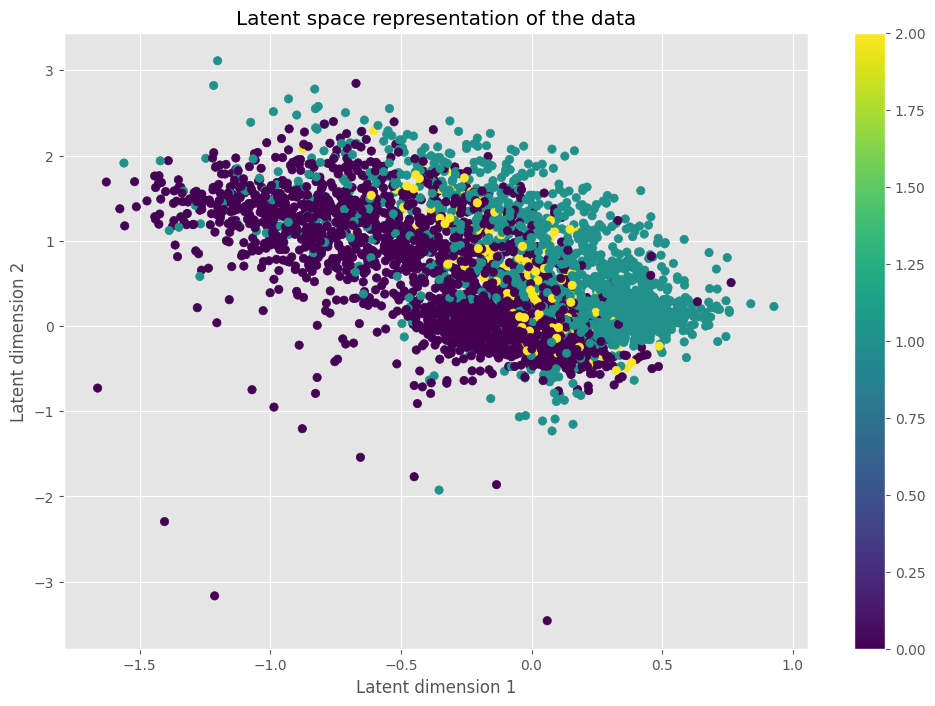

In [52]:
z_loc, z_scale = vae.encoder(torch.tensor(X_train), torch.tensor(y_train))
z_loc = z_loc.cpu().detach().numpy()
z_scale = z_scale.cpu().detach().numpy()
plt.scatter(z_loc[:,0], z_loc[:,1], c=y_train)
plt.colorbar()
# print labels with colorbar
plt.title("Latent space representation of the data")
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.show()



# Explore Latent Space

y_embed: tensor([[ 0.0861, -0.0448,  0.0013,  ...,  0.0224,  0.0252,  0.0033],
        [-0.0866, -0.1342, -0.0273,  ...,  0.0230, -0.0398,  0.1535],
        [ 0.0861, -0.0448,  0.0013,  ...,  0.0224,  0.0252,  0.0033],
        ...,
        [-0.0866, -0.1342, -0.0273,  ...,  0.0230, -0.0398,  0.1535],
        [-0.1327,  0.0274, -0.0078,  ..., -0.0614, -0.0666, -0.0529],
        [ 0.0861, -0.0448,  0.0013,  ...,  0.0224,  0.0252,  0.0033]],
       grad_fn=<EmbeddingBackward0>)
xy: tensor([[-0.4289,  0.6515,  0.2838,  ...,  0.0224,  0.0252,  0.0033],
        [ 0.2455, -0.2655, -0.6498,  ...,  0.0230, -0.0398,  0.1535],
        [-0.6204, -0.2655, -0.7939,  ...,  0.0224,  0.0252,  0.0033],
        ...,
        [-0.2444, -0.2655,  0.7446,  ...,  0.0230, -0.0398,  0.1535],
        [-0.3403, -0.2655, -1.7749,  ..., -0.0614, -0.0666, -0.0529],
        [-0.0440, -0.2655, -0.3409,  ...,  0.0224,  0.0252,  0.0033]],
       grad_fn=<CatBackward0>)
hidden: tensor([[0.0099, 0.2205, 2.7265,  ..., 0.43

/Users/jesperjorgen/Library/Python/3.9/lib/python/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


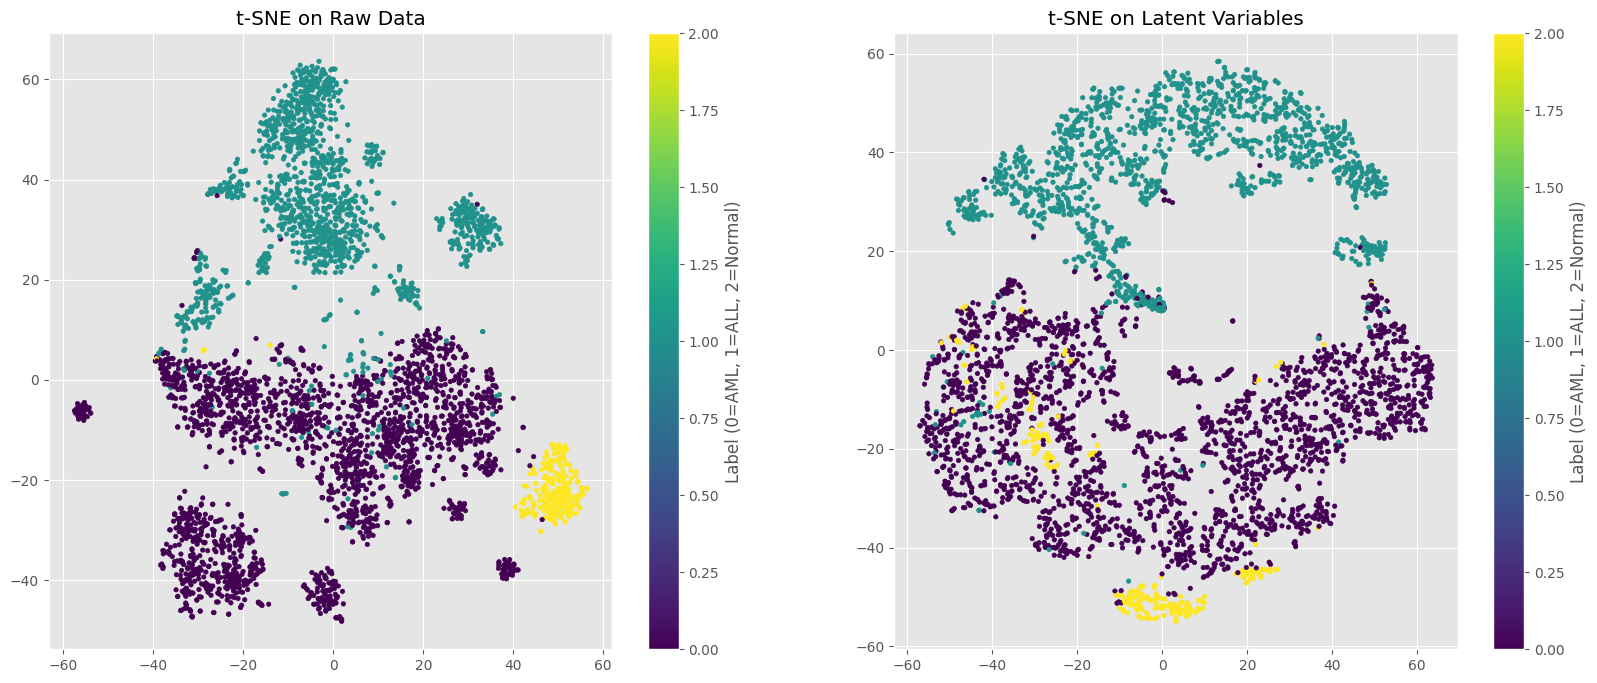

In [27]:
def TSNE_plots(z_loc, labels,observed_data):
    raw_data_tsne = TSNE(n_components=2).fit_transform(observed_data)
    z_post_tsne = TSNE(n_components=2).fit_transform(z_loc.detach().cpu().numpy())

    # subplot 1: t-SNE on raw data
    plt.figure(figsize=(20, 8))
    plt.subplot(1, 2, 1)
    plt.scatter(raw_data_tsne[:, 0], raw_data_tsne[:, 1], c=labels.flatten(), cmap='viridis', s=10)
    plt.title("t-SNE on Raw Data")
    plt.colorbar(label='Label (0=AML, 1=ALL, 2=Normal)')
    plt.subplot(1, 2, 2)
    plt.scatter(z_post_tsne[:, 0], z_post_tsne[:, 1], c=labels.flatten(), cmap='viridis', s=10)
    plt.title("t-SNE on Latent Variables")
    plt.colorbar(label='Label (0=AML, 1=ALL, 2=Normal)')
    plt.show()


z_loc, z_scale = vae.encoder(X_train, y_train)
TSNE_plots(z_loc, y_train,X_train.cpu().detach().numpy())

We can now look at the reconstructions produced by the VAE model for a subset of the digits in the dataset:

In [ ]:
print(list(pyro.get_param_store().keys()))

['encoder$$$label_embed.weight', 'encoder$$$fc1.weight', 'encoder$$$fc1.bias', 'encoder$$$fc21.weight', 'encoder$$$fc21.bias', 'encoder$$$fc22.weight', 'encoder$$$fc22.bias', 'decoder$$$label_embed.weight', 'decoder$$$fc1.weight', 'decoder$$$fc1.bias', 'decoder$$$fc21.weight', 'decoder$$$fc21.bias', 'decoder$$$fc22.weight', 'decoder$$$fc22.bias']


As we can see, the observations of the different digits are nicely separated (clustered) in the latent space $\textbf{z}$. I.e., all observations of the digit 5 are clustered together in the latent space, and similarly for other digits.

Lastly, since the VAE is a generative model, we can use it to sample new observations ("fake data"). We can do this by sampling $z$ from a standard Gaussian distribution and passing those samples through the decoder network. 

As you can see, some samples are somewhat realistic images of digits, while others are clearly not. You can probably obtain better samples (i.e., more realistic) if you train the VAE for longer.

/var/folders/8t/d6_11l453sn6_8s_y198yz_r0000gn/T/ipykernel_32532/1711512121.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  z_loc, _ = vae.encoder(torch.tensor(X_train), torch.tensor(y_train))  # CVAE encoder requires both X and y


y_embed: tensor([[ 0.0861, -0.0448,  0.0013,  ...,  0.0224,  0.0252,  0.0033],
        [-0.0866, -0.1342, -0.0273,  ...,  0.0230, -0.0398,  0.1535],
        [ 0.0861, -0.0448,  0.0013,  ...,  0.0224,  0.0252,  0.0033],
        ...,
        [-0.0866, -0.1342, -0.0273,  ...,  0.0230, -0.0398,  0.1535],
        [-0.1327,  0.0274, -0.0078,  ..., -0.0614, -0.0666, -0.0529],
        [ 0.0861, -0.0448,  0.0013,  ...,  0.0224,  0.0252,  0.0033]])
xy: tensor([[-0.4289,  0.6515,  0.2838,  ...,  0.0224,  0.0252,  0.0033],
        [ 0.2455, -0.2655, -0.6498,  ...,  0.0230, -0.0398,  0.1535],
        [-0.6204, -0.2655, -0.7939,  ...,  0.0224,  0.0252,  0.0033],
        ...,
        [-0.2444, -0.2655,  0.7446,  ...,  0.0230, -0.0398,  0.1535],
        [-0.3403, -0.2655, -1.7749,  ..., -0.0614, -0.0666, -0.0529],
        [-0.0440, -0.2655, -0.3409,  ...,  0.0224,  0.0252,  0.0033]])
hidden: tensor([[0.0099, 0.2205, 2.7265,  ..., 0.4307, 2.5682, 0.6563],
        [0.7570, 2.5546, 0.9779,  ..., 0.3587, 

/var/folders/8t/d6_11l453sn6_8s_y198yz_r0000gn/T/ipykernel_32532/1711512121.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Z_train_np =  torch.tensor(z_loc).numpy()
/var/folders/8t/d6_11l453sn6_8s_y198yz_r0000gn/T/ipykernel_32532/1711512121.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  z_test, _ = vae.encoder(torch.tensor(X_test), torch.tensor(y_test))


y_embed: tensor([[ 0.0861, -0.0448,  0.0013,  ...,  0.0224,  0.0252,  0.0033],
        [-0.0866, -0.1342, -0.0273,  ...,  0.0230, -0.0398,  0.1535],
        [-0.1327,  0.0274, -0.0078,  ..., -0.0614, -0.0666, -0.0529],
        ...,
        [ 0.0861, -0.0448,  0.0013,  ...,  0.0224,  0.0252,  0.0033],
        [ 0.0861, -0.0448,  0.0013,  ...,  0.0224,  0.0252,  0.0033],
        [-0.0866, -0.1342, -0.0273,  ...,  0.0230, -0.0398,  0.1535]])
xy: tensor([[-0.4676, -0.2099,  0.0251,  ...,  0.0224,  0.0252,  0.0033],
        [ 0.7463,  0.4883,  1.0375,  ...,  0.0230, -0.0398,  0.1535],
        [ 0.0198, -0.2099, -1.3941,  ..., -0.0614, -0.0666, -0.0529],
        ...,
        [ 0.2852,  1.2387,  0.2287,  ...,  0.0224,  0.0252,  0.0033],
        [-0.2352, -0.2099, -0.8003,  ...,  0.0224,  0.0252,  0.0033],
        [-0.5981, -0.2099,  0.8148,  ...,  0.0230, -0.0398,  0.1535]])
hidden: tensor([[1.8097e-02, 1.0643e-01, 3.5114e+00,  ..., 7.4582e-01, 8.4836e-01,
         5.2328e-01],
        [3.470

/var/folders/8t/d6_11l453sn6_8s_y198yz_r0000gn/T/ipykernel_32532/1711512121.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Z_test_np =  torch.tensor(z_test).numpy()


Classification Report from Latent Space:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       504
           1       0.96      0.97      0.97       311
           2       0.94      0.83      0.88        54

    accuracy                           0.96       869
   macro avg       0.96      0.93      0.94       869
weighted avg       0.96      0.96      0.96       869



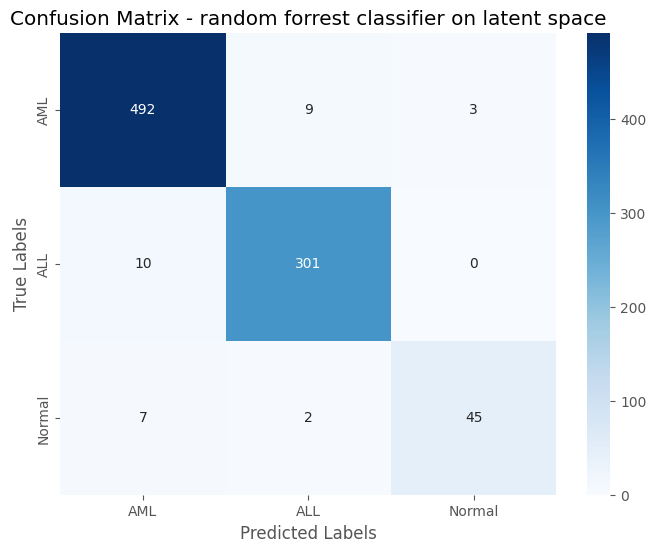

Accuracy of Random Forest Classifier on Latent Space: 0.9643


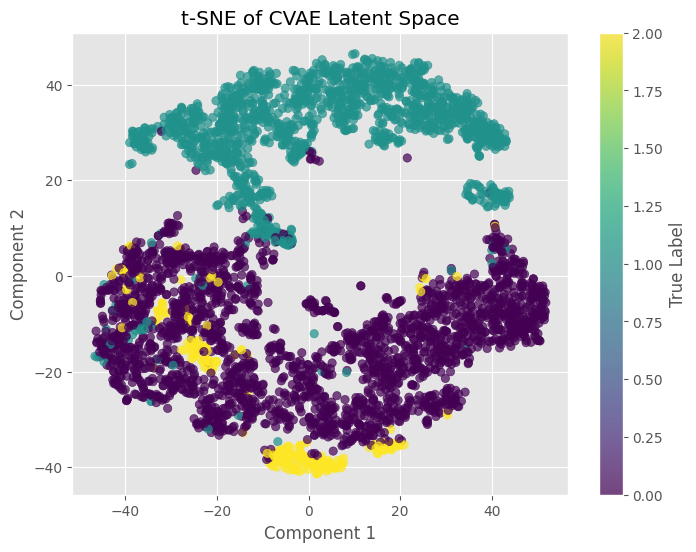

In [ ]:
vae.encoder.eval()
with torch.no_grad():
    z_loc, _ = vae.encoder(torch.tensor(X_train), torch.tensor(y_train))  # CVAE encoder requires both X and y
    Z_train_np =  torch.tensor(z_loc).numpy()
    y_train_np =  torch.tensor(y_train).numpy()
with torch.no_grad():
    z_test, _ = vae.encoder(torch.tensor(X_test), torch.tensor(y_test))
    Z_test_np =  torch.tensor(z_test).numpy()
    y_test_np =  torch.tensor(y_test).numpy()

# Step 3: Train classifier on latent space
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(Z_train_np, y_train_np)

# Step 4: Evaluate classifier
y_pred_np = clf.predict(Z_test_np)
print("Classification Report from Latent Space:")
print(classification_report(y_test_np, y_pred_np))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_np)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["AML", "ALL", "Normal"], yticklabels=["AML", "ALL", "Normal"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - random forrest classifier on latent space")
plt.show()

#accuracy
accuracy = accuracy_score(y_test_np, y_pred_np)
print(f"Accuracy of Random Forest Classifier on Latent Space: {accuracy:.4f}")

# Step 5: Visualize latent space with t-SNE
tsne = TSNE(n_components=2, perplexity=50)
Z_2d = tsne.fit_transform(Z_test_np)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=y_test, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='True Label')
plt.title("t-SNE of CVAE Latent Space")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()


Classification Report from Latent Space (Logistic Regression):
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       504
           1       0.96      0.92      0.94       311
           2       0.92      0.83      0.87        54

    accuracy                           0.94       869
   macro avg       0.94      0.91      0.92       869
weighted avg       0.95      0.94      0.94       869



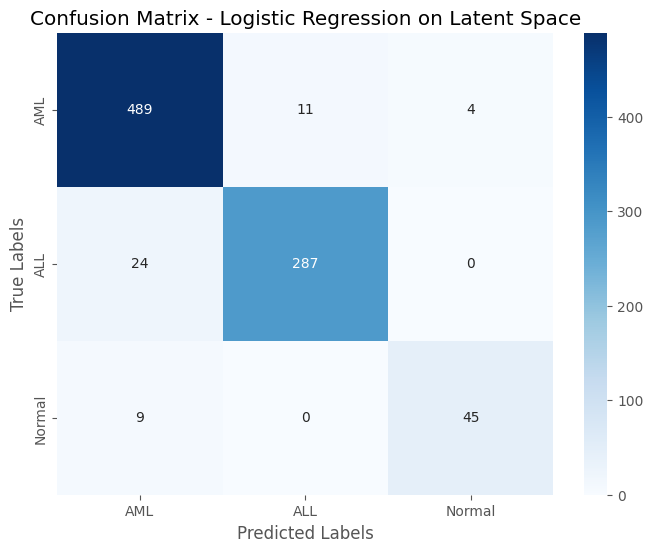

Accuracy of Logistic Regression Classifier on Latent Space: 0.9448


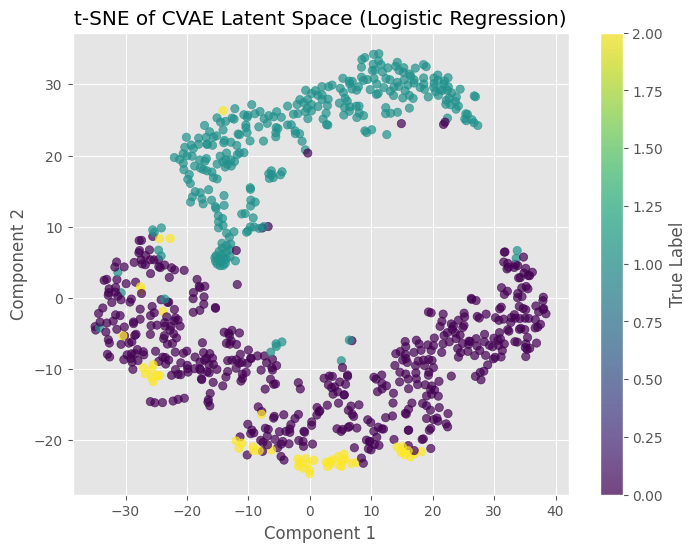

In [44]:
# try logistic regression classifier 
from sklearn.linear_model import LogisticRegression
# Step 6: Train logistic regression classifier on latent space
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(Z_train_np, y_train_np)
# Step 7: Evaluate logistic regression classifier
y_pred_log_reg = log_reg.predict(Z_test_np)
print("Classification Report from Latent Space (Logistic Regression):")
print(classification_report(y_test_np, y_pred_log_reg))
# Confusion matrix for logistic regression
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt="d", cmap="Blues", xticklabels=["AML", "ALL", "Normal"], yticklabels=["AML", "ALL", "Normal"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - Logistic Regression on Latent Space")
plt.show()
#accuracy for logistic regression
accuracy_log_reg = accuracy_score(y_test_np, y_pred_log_reg)
print(f"Accuracy of Logistic Regression Classifier on Latent Space: {accuracy_log_reg:.4f}")    

# Step 8: Visualize latent space with t-SNE for logistic regression
tsne_log_reg = TSNE(n_components=2, random_state=42)
Z_2d_log_reg = tsne_log_reg.fit_transform(Z_test_np)
plt.figure(figsize=(8, 6)) 
scatter_log_reg = plt.scatter(Z_2d_log_reg[:, 0], Z_2d_log_reg[:, 1], c=y_test, cmap='viridis', alpha=0.7)
plt.colorbar(scatter_log_reg, label='True Label')
plt.title("t-SNE of CVAE Latent Space (Logistic Regression)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()

